In [1]:
from google.colab import files
uploaded = files.upload()

Saving advertising.csv to advertising.csv


First 5 Rows:
   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Dataset Shape:
(200, 5)


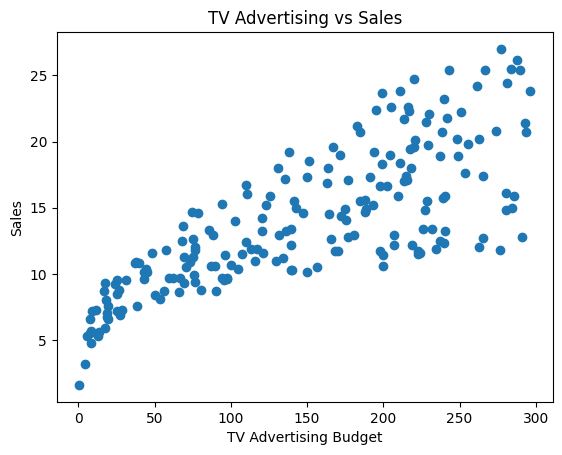


Mean Absolute Error: 1.4607567168117603
R2 Score: 0.899438024100912
   Actual Sales  Predicted Sales
0          16.9        16.408024
1          22.4        20.889882
2          21.4        21.553843
3           7.3        10.608503
4          24.7        22.112373
5          12.6        13.105592
6          22.3        21.057192
7           8.4         7.461010
8          11.5        13.606346
9          14.9        15.155070


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Load Dataset
df = pd.read_csv("advertising.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

# Visualization
plt.scatter(df['TV'], df['sales'])
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("TV Advertising vs Sales")
plt.show()

# Features and Target
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
predictions = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\nMean Absolute Error:", mae)
print("R2 Score:", r2)

# Sample Predictions
result = pd.DataFrame({
    'Actual Sales': y_test.values[:10],
    'Predicted Sales': predictions[:10]
})

print(result)